In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')  

## Importacion de los Datasets

#### PremierLeague

In [8]:
PremierLeague_21_22 = pd.read_csv("England_PL\\21-22\preprocessed_EPL_21-22.csv")
PremierLeague_22_23 = pd.read_csv("England_PL\\22-23\preprocessed_EPL_22-23.csv")
PremierLeague_23_24 = pd.read_csv("England_PL\\23-24\preprocessed_EPL_23-24.csv")
PremierLeague_24_25 = pd.read_csv("England_PL\\24-25\preprocessed_EPL_24-25.csv")
PremierLeague_25_26 = pd.read_csv("England_PL\\25-26\preprocessed_EPL_25-26.csv")

In [2]:
PremierLeague_23_24 = pd.read_csv("England_PL\\23-24\preprocessed_EPL_23-24.csv")

In [4]:
print(len(PremierLeague_21_22))
print(len(PremierLeague_22_23))
print(len(PremierLeague_23_24))
# print(len(PremierLeague_24_25))
# print(len(PremierLeague_25_29))

573521
577159
590475


#### Serie A

In [3]:

SerieA_21_22 = pd.read_csv("Italy Serie A\\21-22\preprocessed_ISA_21-22.csv")
SerieA_22_23 = pd.read_csv("Italy Serie A\\22-23\preprocessed_ISA_22-23.csv")
SerieA_23_24 = pd.read_csv("Italy Serie A\\23-24\preprocessed_ISA_23-24.csv")
SerieA_24_25 = pd.read_csv("Italy Serie A\\24-25\preprocessed_ISA_24-25.csv")
SerieA_25_26 = pd.read_csv("Italy Serie A\\25-26\preprocessed_ISA_25-26.csv")

C:\Users\bauti\AppData\Local\Temp\ipykernel_14384\2290502892.py:1: DtypeWarning: Columns (47,48) have mixed types. Specify dtype option on import or set low_memory=False.
  SerieA_21_22 = pd.read_csv("Italy Serie A\\21-22\preprocessed_ISA_21-22.csv")
C:\Users\bauti\AppData\Local\Temp\ipykernel_14384\2290502892.py:2: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  SerieA_22_23 = pd.read_csv("Italy Serie A\\22-23\preprocessed_ISA_22-23.csv")
C:\Users\bauti\AppData\Local\Temp\ipykernel_14384\2290502892.py:3: DtypeWarning: Columns (21,47,48) have mixed types. Specify dtype option on import or set low_memory=False.
  SerieA_23_24 = pd.read_csv("Italy Serie A\\23-24\preprocessed_ISA_23-24.csv")


#### LaLiga2

## Analisis Exploratorio

#### Columnas de los Dataframes

In [ ]:
def columnas_son_iguales(*dfs):
    base = set(dfs[0].columns)
    
    for i, df in enumerate(dfs[1:], 2):
        if base == set(df.columns):
            print(f"df1 y df{i}: ✅ Iguales")
        else:
            diff = base.symmetric_difference(set(df.columns))
            print(f"df1 y df{i}: ❌ Distintos → Diferencias: {diff}")

# Uso:
columnas_son_iguales(
    SerieA_21_22,
    SerieA_22_23,
    SerieA_23_24,
    SerieA_24_25,
    SerieA_25_26,
    PremierLeague_21_22,
    PremierLeague_22_23,
    PremierLeague_23_24,
    PremierLeague_24_25,
    PremierLeague_25_26
)

df1 y df2: ✅ Iguales
df1 y df3: ✅ Iguales
df1 y df4: ✅ Iguales
df1 y df5: ✅ Iguales
df1 y df6: ❌ Distintos → Diferencias: {'Posesion_id', 'original_id'}
df1 y df7: ❌ Distintos → Diferencias: {'Posesion_id', 'original_id'}
df1 y df8: ❌ Distintos → Diferencias: {'Posesion_id', 'original_id'}
df1 y df9: ❌ Distintos → Diferencias: {'Posesion_id', 'original_id'}
df1 y df10: ❌ Distintos → Diferencias: {'Posesion_id', 'original_id'}


In [8]:
#Cantidad de pases por temporada
dfs_SerieA = [
    SerieA_21_22,
    SerieA_22_23,
    SerieA_23_24,
    SerieA_24_25,
]
dfs_PL = [
    PremierLeague_21_22,
    PremierLeague_22_23,
    PremierLeague_23_24,
    PremierLeague_24_25,
]

Total_SA = 0
Total_PL = 0
for i, df in enumerate(dfs_SerieA):
    Temporada = 21 + i
    pases = len(df[df['event_name'] == 'Pass'])
    Total_SA += pases
    print(f"Temporada {Temporada} / {Temporada+1}:", pases)

print("Promedio Serie A:", Total_SA/4)

for i, df in enumerate(dfs_PL):
    Temporada = 21 + i
    pases = len(df[df['event_name'] == 'Pass'])
    Total_PL += pases
    print(f"Temporada {Temporada} / {Temporada+1}:", pases)

print("Promedio PL:", Total_PL/4)



Temporada 21 / 22: 360098
Temporada 22 / 23: 355230
Temporada 23 / 24: 362508
Temporada 24 / 25: 315481
Promedio Serie A: 348329.25
Temporada 21 / 22: 373541
Temporada 22 / 23: 374281
Temporada 23 / 24: 387581
Temporada 24 / 25: 289921
Promedio PL: 356331.0


Decido trabajar con las temporadas de Premier League 21/22; 22/23; 23/24
Para el primer analisis utilizare la temporada 23/24 

### Primer Analisis (Serie A)
_Poco valor_ 


In [13]:
# SerieA_21_22.head(50)
#Teams > TeamName	
#players > jugador
#Matches > matchId

def Matches_Teams_Players(df):
    #Cantidad de equipos
    print("Teams : \t", len(df["TeamName"].unique()))
    
    #Cantidad de jugadores
    print("Players : \t", len(df["jugador"].unique()))
    
    #Cantidad de partidos
    print("Matches : \t",len(df["matchId"].unique()))
    print("Matches : \t",len((df['TeamName'].astype(str) + ' - ' + df['TeamRival'].astype(str)).unique()))


Matches_Teams_Players(SerieA_21_22)

Teams : 	 20
Players : 	 610
Matches : 	 374
Matches : 	 380


In [23]:
def encontrar_faltantes(lista):
    completa = set(range(min(lista), max(lista) + 1))
    faltantes = sorted(completa - set(lista))
    return faltantes

encontrar_faltantes(SerieA_21_22["matchId"].unique())

[1575817, 1575876, 1575881, 1575889, 1575891, 1575896]

In [19]:
Inter_Milan_21_22 = SerieA_21_22[SerieA_21_22["matchId"] == 1576024]

#Inter 1-2 Milan Jornada 24
#Ejemplo para qualifiers

Inter_Milan_21_22[50:100]["qualifiers"][350691]

"[{'type': {'value': 141, 'displayName': 'PassEndY'}, 'value': '95.7'}, {'type': {'value': 212, 'displayName': 'Length'}, 'value': '8.8'}, {'type': {'value': 140, 'displayName': 'PassEndX'}, 'value': '91.8'}, {'type': {'value': 213, 'displayName': 'Angle'}, 'value': '3.4'}, {'type': {'value': 178, 'displayName': 'StandingSave'}}, {'type': {'value': 6, 'displayName': 'CornerTaken'}}, {'type': {'value': 56, 'displayName': 'Zone'}, 'value': 'Left'}]"

qualifiers: metainformacion de la accion
isTouch: toque de balon
goalMouth: Donde termina el tiro
relatedEventId: Eventos que van de la mano (ejemplo tiro y safes)
relatedPlayerId: No darle bola
ataja_disp: Arquero del otro equipo si ataja tiro
Posesion: Segudilla de pases
time_since_previous_action: delta diferencia accion anterior

In [ ]:
cols = ['minute', 'second', 'teamId', 'x', 'y', 'satisfiedEventsTypes', 'isTouch', 'playerId', 'endX',
       'endY', 'isGoal', 'isShot', 'event_name',
       'outcome_type', 'jugador', 'equipo vs', 'matchId',
       'fecha', 'Competencia', 'Temporada', 'position', 'TeamName',
       'TeamRival', 'receiver_position',
       'receiver_playerName', 'receiver_playerId', 'time_seconds',
       'time_since_previous_action', 'previous_event', 'next_event_posesion',
       'id_formation', 'id_formation_rival', 'xG', 'xG_corr', 'xGoT',
       'xGoT_corr', 'id', 'xA', 'xT', 'goal_int', 'goles_equipo',
       'goles_totales', 'goles_rival', 'estado_partido']

Inter_Milan_21_22[Inter_Milan_21_22["receiver_playerName"].notna()]["event_name"].unique() #[['minute', 'second',"jugador", "TeamName", "event_name","outcome_type",  "receiver_position","receiver_playerName"]]

array(['Pass'], dtype=object)

In [ ]:
Inter_Milan_21_22["event_name"].unique()
#Deberiamos tomar como "interaccion" segun como empieza la jugada
#Yo creo que una interaccion va a ser un pase/despeje/lo que sea (analisar) que empiece con intencion
#Y termine en un jugador del mismo equipo

array(['FormationSet', 'Start', 'Pass', 'Interception', 'BallTouch',
       'BallRecovery', 'Clearance', 'BlockedPass', 'Foul', 'Aerial',
       'Claim', 'KeeperPickup', 'TakeOn', 'Tackle', 'OffsideGiven',
       'Dispossessed', 'OffsidePass', 'OffsideProvoked', 'SavedShot',
       'Save', 'ShieldBallOpp', 'MissedShots', 'Card', 'Punch', 'Goal',
       'SubstitutionOff', 'SubstitutionOn', 'KeeperSweeper', 'End',
       'ChanceMissed', 'FormationChange'], dtype=object)

### Primer Analisis Premier League 23/24

#### Matches_Teams_Players

In [ ]:
def Matches_Teams_Players(df):
    #Cantidad de equipos
    print("Teams : \t", len(df["TeamName"].unique()))
    
    #Cantidad de jugadores
    print("Players : \t", len(df["jugador"].unique()))
    
    #Cantidad de partidos
    print("Matches : \t",len(df["matchId"].unique()))
    print("Matches : \t",len((df['TeamName'].astype(str) + ' - ' + df['TeamRival'].astype(str)).unique()))


Matches_Teams_Players(PremierLeague_23_24)
#Estan todos los partidos


Teams : 	 20
Players : 	 573
Matches : 	 380
Matches : 	 380


#### Analisis de eventos (cantidad y outcome)

In [18]:
# Eventos por event_name con descripcion
descripciones = {
    'Pass': 'Pase a un compañero',
    'BallTouch': 'Toque de balón sin pase',
    'BallRecovery': 'Recuperación del balón',
    'Clearance': 'Despeje',
    'BlockedPass': 'Pase bloqueado por rival',
    'Foul': 'Falta cometida',
    'Aerial': 'Duelo aéreo',
    'Claim': 'Arquero atrapa el balón',
    'KeeperPickup': 'Arquero recoge con las manos',
    'TakeOn': 'Intento de gambeta',
    'Tackle': 'Entrada/tackle al rival',
    'OffsideGiven': 'Offside cobrado',
    'Dispossessed': 'Jugador pierde el balón',
    'OffsidePass': 'Pase en posición de offside',
    'OffsideProvoked': 'Offside provocado al rival',
    'SavedShot': 'Tiro al arco atajado',
    'Save': 'Atajada del arquero',
    'ShieldBallOpp': 'Jugador protege el balón del rival',
    'MissedShots': 'Tiro desviado o al palo',
    'Card': 'Tarjeta amarilla o roja',
    'Punch': 'Arquero rechaza de puño',
    'Goal': 'Gol',
    'ChanceMissed': 'Chance de gol desperdiciada',
    'KeeperSweeper': 'Arquero sale a cortar',
    'Interception': 'Intercepción del balón',
    'SubstitutionOff': 'Jugador sale del partido',
    'SubstitutionOn': 'Jugador entra al partido',
    'FormationSet': 'Formación inicial registrada',
    'FormationChange': 'Cambio de formación',
    'Start': 'Inicio de período',
    'End': 'Fin de período',
    'Error': 'Error del jugador que genera chance rival',
    'ShotOnPost': 'Tiro que pega en el palo',
    'PenaltyFaced': 'Penal que enfrenta el arquero',
    'Smother': 'Arquero cierra el ángulo y tapa',
    'GoodSkill': 'Habilidad técnica destacada',
    'CrossNotClaimed': 'Centro no atrapado por el arquero',
}

def eventos_por_tipo(df):
    resultado = (
        df.groupby('event_name')
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
    )
    resultado['descripcion'] = resultado['event_name'].map(descripciones)
    return resultado

In [26]:
Eventos_PL_23_24 = eventos_por_tipo(PremierLeague_23_24)
Eventos_PL_23_24.head()

,event_name,count,descripcion
24,Pass,387581,Pase a un compañero
1,BallRecovery,36689,Recuperación del balón
2,BallTouch,24954,Toque de balón sin pase
0,Aerial,20303,Duelo aéreo
14,Foul,16811,Falta cometida


In [27]:
eventos_por_tipo(PremierLeague_23_24[PremierLeague_23_24["outcome_type"] == "Successful"]).head()


,event_name,count,descripcion
22,Pass,314050,Pase a un compañero
1,BallRecovery,36689,Recuperación del balón
6,Clearance,15582,Despeje
2,BallTouch,14162,Toque de balón sin pase
0,Aerial,10151,Duelo aéreo


In [ ]:
def eventos_por_tipo(df):
    total = df.groupby('event_name').size().reset_index(name='count')
    exitosos = df[df['outcome_type'] == 'Successful'].groupby('event_name').size().reset_index(name='exitosos')
    
    resultado = total.merge(exitosos, on='event_name', how='left')
    resultado['exitosos'] = resultado['exitosos'].fillna(0)
    resultado['pct_exitoso'] = (resultado['exitosos'] / resultado['count'] * 100).round(1)
    resultado['descripcion'] = resultado['event_name'].map(descripciones)
    
    return resultado.drop(columns='exitosos').sort_values('count', ascending=False)

eventos_por_tipo(PremierLeague_23_24).head()


,event_name,count,pct_exitoso,descripcion
24,Pass,387581,81.0,Pase a un compañero
1,BallRecovery,36689,100.0,Recuperación del balón
2,BallTouch,24954,56.8,Toque de balón sin pase
0,Aerial,20303,50.0,Duelo aéreo
14,Foul,16811,50.0,Falta cometida


#### Analisis en profundida por evento

In [ ]:
PremierLeague_23_24[5000:50010]
Col_nt = ["eventId", "second", "teamId", "satisfiedEventsTypes", "blockedX", "blockedY",
            "cardType", "period_name","ataja_disp", "equipo vs","matchId","fecha","Competencia",
            "Temporada", "original_id", "Posesion_id", "Posesion","time_seconds", "xG", "xGoT",
            "goal_int", "goles_equipo", "goles_totales", "goles_totales", "goles_rival", 
            "estado_partido", "isTouch", "isGoal", "isShot"
            ]

Col_Count = ["jugador", "position", "receiver_position", "receiver_playerName", "previous_event",
                "next_event_posesion", "period_id"]

Col_num = ["minute", "x", "y", "endX", "endY", "time_since_previous_action", "xG_corr", 
            "xGoT_corr", "xA", "xT", "goalMouthZ", "goalMouthY", ]

Col_ver = ["qualifiers", "event_id", "event_name", "outcome_value", "outcome_type"]

In [ ]:
#Con las numericas me interesa promedio y desvest
#Con las Count me interesa: Cantidad de NaN, y cantidad del top 5 (si hay menos de 5 los que haya)
#Ver:   
#   qualifiers (Nada, pero por dificil)
#   event_id, event name (titulo)
# "outcome_value", "outcome_type" Salen como el anterior, con porcentaje

In [140]:
from IPython.display import display, HTML

def _add_col_to_serie(serie, subset, col):
    nans = subset[col].isna().sum()
    serie[f'{col}_nan'] = nans

    TOP_N = {
    'jugador': 3,
    'previous_event': 3,
    'next_event_posesion': 3,
    }

    if col == 'period_id':
        vc = subset[col].value_counts()
        for period in [1, 2]:
            serie[f'period_id_{period}_count'] = vc.get(period, 0)
    else:
        n = TOP_N.get(col, 1)
        top = subset[col].value_counts().head(n)
        for i, (val, cnt) in enumerate(top.items(), 1):
            serie[f'{col}_top{i}']       = val
            serie[f'{col}_top{i}_count'] = cnt

def _cat_block(subset, cols):
    html = ""
    for col in cols:
        nans = subset[col].isna().sum()
        top  = subset[col].value_counts().head(5)
        top_df = top.reset_index()
        top_df.columns = [col, 'count']
        html += f"<b>{col}</b> — NaN: {nans:,}<br>" + top_df.to_html(index=False) + "<br>"
    return html

def analisis_evento(df, event_name, dplay=True):
    subset = df[df['event_name'] == event_name]
    n = len(subset)
    serie = {}

    # --- Numéricas ---
    col_num_pres = [c for c in Col_num if c in subset.columns]
    num_html = ""
    if col_num_pres:
        stats = subset[col_num_pres].agg(['mean', 'std']).T.round(3)
        stats.columns = ['Media', 'Desvio std']
        for col in col_num_pres:
            serie[f'{col}_mean'] = stats.loc[col, 'Media']
            serie[f'{col}_std']  = stats.loc[col, 'Desvio std']
        num_html = stats.to_html()

    # --- Outcome (solo outcome_type) ---
    outcome_html = ""
    if 'outcome_type' in subset.columns:
        nans = subset['outcome_type'].isna().sum()
        vc   = subset['outcome_type'].value_counts()
        out  = pd.DataFrame({'count': vc, '%': (vc / n * 100).round(1)}).head(5)
        for val, row in out.iterrows():
            serie[f'outcome_type_{val}_pct'] = row['%']
        outcome_html = f"<br><b>outcome_type</b> — NaN: {nans:,}<br>" + out.to_html()

    # --- Categóricas divididas en 2 ---
    col_count_pres = [c for c in Col_Count if c in subset.columns]
    for col in col_count_pres:
        _add_col_to_serie(serie, subset, col)

    mid = len(col_count_pres) // 2 + len(col_count_pres) % 2
    cat_html_1 = _cat_block(subset, col_count_pres[:mid])
    cat_html_2 = _cat_block(subset, col_count_pres[mid:])

    # --- Layout HTML ---
    if dplay == True:
        html = f"""
        <style>td table {{ width: auto !important; }}</style>
        <h1>{event_name} &mdash; {n:,} eventos</h1>
        <table width="100%" style="border-collapse:collapse"><tr>
            <td valign="top" width="25%">
                <b>Numéricas</b><br>{num_html}{outcome_html}
            </td>
            <td valign="top" width="37%">
                <b>Categóricas (1/2)</b><br>{cat_html_1}
            </td>
            <td valign="top" width="38%">
                <b>Categóricas (2/2)</b><br>{cat_html_2}
            </td>
        </tr></table>
        """
        display(HTML(html))

    return pd.Series(serie, name=event_name)

In [ ]:
eventos_por_tipo(PremierLeague_23_24)

In [141]:
analisis_evento(PremierLeague_23_24, "TakeOn")
print()

,Media,Desvio std
minute,48.850,27.825
x,61.897,22.733
y,51.315,31.739
endX,NaN,NaN
endY,NaN,NaN
time_since_previous_action,2.468,1.980
xG_corr,NaN,NaN
xGoT_corr,NaN,NaN
xA,NaN,NaN
xT,NaN,NaN


In [145]:
def comparativa_efectiva(df, events, Nans = "NADA"):
    '''
    Nans: Decide que hacer con los Nans
        - NADA (defecto): Los deja
        - TODOS: Elimina toda fila que tenga algun NaN
        - FILA: Elimina las filas que tienen algun NaN
        - int: Cuantos Nan permito por fila
    '''
    eventos = analisis_evento(df, events[0], False)
    for e in events[1:]:
        eventos = pd.concat([eventos,analisis_evento(df, e, False),], axis=1)
    match Nans:
        case "NADA":
            pass
        case "TODOS":
            eventos = eventos.dropna()
        case "FILA":
            eventos = eventos.dropna(how='all')
        case int(n):
            tresh = len(events) - n
            eventos = eventos.dropna(thresh=tresh)
    
    return eventos


In [143]:
comparativa_efectiva(PremierLeague_23_24, ("Pass", "Goal", "TakeOn"), 0)

,Pass,Goal,TakeOn
minute_mean,45.979,51.594,48.85
minute_std,27.707,27.112,27.825
x_mean,47.858,86.603,61.897
x_std,23.31,17.453,22.733
y_mean,49.893,49.784,51.315
y_std,29.153,8.318,31.739
time_since_previous_action_mean,4.755,11.748,2.468
time_since_previous_action_std,9.001,36.718,1.98
outcome_type_Successful_pct,81.0,100.0,42.9
jugador_nan,0,0,0


In [146]:
comparativa_efectiva(PremierLeague_23_24, ("Pass", "Goal", "TakeOn", 
                                           "BallRecovery", "BallTouch", "Aerial", "Foul"), 0)

,Pass,Goal,TakeOn,BallRecovery,BallTouch,Aerial,Foul
minute_mean,45.979,51.594,48.85,46.81,47.724,49.153,48.93
minute_std,27.707,27.112,27.825,27.859,28.054,28.317,27.765
x_mean,47.858,86.603,61.897,38.033,53.112,50.0,50.0
x_std,23.31,17.453,22.733,20.157,26.217,26.69,22.093
y_mean,49.893,49.784,51.315,50.803,50.185,49.998,49.999
y_std,29.153,8.318,31.739,28.848,29.342,24.412,29.97
time_since_previous_action_mean,4.755,11.748,2.468,1.767,1.316,1.126,1.186
time_since_previous_action_std,9.001,36.718,1.98,2.429,1.703,1.402,1.751
outcome_type_Successful_pct,81.0,100.0,42.9,100.0,56.8,50.0,50.0
jugador_nan,0,0,0,0,0,0,295


#### Analisis de Posiciones

In [147]:
PremierLeague_23_24["position"].unique()

array([nan, 'FWR', 'DC', 'MC', 'DL', 'FWL', 'GK', 'DML', 'DR', 'FW',
       'DMR', 'Sub', 'ML', 'DMC', 'AML', 'AMR', 'MR', 'AMC'], dtype=object)

In [149]:
descripciones_posicion = {
    'GK':  'Arquero',
    'DC':  'Defensor central',
    'DL':  'Lateral izquierdo',
    'DR':  'Lateral derecho',
    'DML': 'Mediocampista defensivo izquierdo',
    'DMR': 'Mediocampista defensivo derecho',
    'DMC': 'Mediocampista defensivo central',
    'ML':  'Mediocampista izquierdo',
    'MR':  'Mediocampista derecho',
    'MC':  'Mediocampista central',
    'AML': 'Extremo izquierdo',
    'AMR': 'Extremo derecho',
    'AMC': 'Mediocampista ofensivo central',
    'FWL': 'Delantero izquierdo',
    'FWR': 'Delantero derecho',
    'FW':  'Delantero centro',
    'Sub': 'Suplente sin posicion definida',
}

def jugadores_por_posicion(df):
    resultado = (
        df.dropna(subset=['position'])
        .groupby('position')['jugador']
        .nunique()
        .reset_index(name='jugadores')
        .sort_values('jugadores', ascending=False)
    )
    resultado['descripcion'] = resultado['position'].map(descripciones_posicion)
    return resultado

In [154]:
jugadores_por_posicion(PremierLeague_23_24)

,position,jugadores,descripcion
16,Sub,491,Suplente sin posicion definida
13,MC,131,Mediocampista central
3,DC,114,Defensor central
9,FW,88,Delantero centro
0,AMC,86,Mediocampista ofensivo central
4,DL,78,Lateral izquierdo
5,DMC,73,Mediocampista defensivo central
8,DR,67,Lateral derecho
1,AML,60,Extremo izquierdo
2,AMR,54,Extremo derecho


#### Analisis de Qualifiers

In [176]:
import random
for i in range(10):
    p = random.randint(0, len(PremierLeague_23_24))
    print(PremierLeague_23_24['qualifiers'][p])

[{'type': {'value': 213, 'displayName': 'Angle'}, 'value': '4.99'}, {'type': {'value': 212, 'displayName': 'Length'}, 'value': '12.5'}, {'type': {'value': 56, 'displayName': 'Zone'}, 'value': 'Left'}, {'type': {'value': 107, 'displayName': 'ThrowIn'}}, {'type': {'value': 141, 'displayName': 'PassEndY'}, 'value': '84.0'}, {'type': {'value': 140, 'displayName': 'PassEndX'}, 'value': '62.0'}]
[{'type': {'value': 213, 'displayName': 'Angle'}, 'value': '1.83'}, {'type': {'value': 141, 'displayName': 'PassEndY'}, 'value': '17.7'}, {'type': {'value': 178, 'displayName': 'StandingSave'}}, {'type': {'value': 140, 'displayName': 'PassEndX'}, 'value': '56.8'}, {'type': {'value': 212, 'displayName': 'Length'}, 'value': '9.1'}, {'type': {'value': 56, 'displayName': 'Zone'}, 'value': 'Right'}]
[{'type': {'value': 56, 'displayName': 'Zone'}, 'value': 'Back'}, {'type': {'value': 178, 'displayName': 'StandingSave'}}]
[{'type': {'value': 213, 'displayName': 'Angle'}, 'value': '4.75'}, {'type': {'value':

In [ ]:
Q_ex = [{'type': {'value': 213, 'displayName': 'Angle'}, 'value': '6.05'}, 
        {'type': {'value': 141, 'displayName': 'PassEndY'}, 'value': '88.5'}, 
        {'type': {'value': 140, 'displayName': 'PassEndX'}, 'value': '50.0'}, 
        {'type': {'value': 56, 'displayName': 'Zone'}, 'value': 'Left'}, 
        {'type': {'value': 212, 'displayName': 'Length'}, 'value': '19.3'}, 
        {'type': {'value': 178, 'displayName': 'StandingSave'}}, 
        {'type': {'value': 155, 'displayName': 'Chipped'}}]


In [ ]:
import ast

def build_qualifiers_df(df):
    def parse_row(q_str):
        if not isinstance(q_str, str) or q_str.strip() == '[]':
            return {}
        parsed = ast.literal_eval(q_str)
        return {q['type']['displayName']: q.get('value', True) for q in parsed}

    parsed = df['qualifiers'].apply(parse_row)
    result = pd.DataFrame(parsed.tolist(), index=df['id'])

    for col in result.columns:
        try:
            result[col] = pd.to_numeric(result[col])
        except (ValueError, TypeError):
            pass

    return result

# Esto es carisimo, ojo
# Prueba con muestra chica:
if 2+2==3:
    sample = PremierLeague_23_24
    qualifiers_df = build_qualifiers_df(sample)
    qualifiers_df = qualifiers_df[qualifiers_df.isna().sum().sort_values().index]
    qualifiers_df

,Zone,StandingSave,PassEndY,PassEndX,Length,Angle,OppositeRelatedEvent,Longball,Offensive,Defensive,Chipped,HeadPass,Foul,RelatedEventId,ThrowIn,Cross,RightFoot,Head,GoalMouthY,GoalMouthZ,IntentionalAssist,FreekickTaken,LeftFoot,Assisted,KeyPass,RegularPlay,JerseyNumber,PlayerPosition,ShotAssist,BlockedY,BlockedX,GoalKick,OtherBodyPart,FirstTouch,IndividualPlay,LayOff,CornerTaken,BoxCentre,KeeperThrow,MissHigh,OutOfBoxCentre,Blocked,FormationSlot,OutfielderBlock,LowCentre,Hands,FromCorner,BigChance,Yellow,TeamFormation,TeamPlayerFormation,InvolvedPlayers,CaptainPlayerId,LowLeft,KeeperSaveInTheBox,DivingSave,IndirectFreekickTaken,PlayerCaughtOffside,BigChanceCreated,Throughball,LowRight,Volley,BlockedCross,BoxLeft,ParriedSafe,BoxRight,OverRun,Collected,KeeperSaveObox,MissLeft,MissRight,HighClaim,IntentionalGoalAssist,SetPiece,FastBreak,HighRight,HighLeft,SmallBoxCentre,ParriedDanger,Penalty,HighCentre,AerialFoul,SixYardBlock,LastMan,SmallBoxLeft,DirectFreekick,SmallBoxRight,LeadingToAttempt,Feet,KeeperSaveInSixYard,OneOnOne,LeadingToGoal,DeepBoxLeft,ThrowinSetPiece,GoalDisallowed,DeepBoxRight,SavedOffline,KeeperMissed,OwnGoal,ThirtyFivePlusCentre,Red,SecondYellow,VoidYellowCard,OutOfBoxDeepLeft,FromShotOffTarget,OutOfBoxDeepRight,OutOfBoxRight,KeeperSaved,Obstruction,OutOfBoxLeft,ThirtyFivePlusLeft,ThirtyFivePlusRight,KeeperWentWide,DirectCorner
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1, 24, 43, 26, 4, 30, 22, 5, 20, 28, 10, 7, 8,...","1, 3, 3, 2, 2, 2, 3, 3, 4, 4, 4, 5, 5, 5, 5, 5...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 0, 0, 0, 0,...","319712,83683,315543,364624,315714,97587,342830...",315714.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1, 5, 12, 41, 4, 2, 8, 29, 14, 7, 11, 6, 10, 1...","1, 2, 2, 3, 2, 2, 3, 3, 4, 4, 4, 5, 5, 5, 5, 5...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 0, 0, 0, 0,...","316858,238940,388650,332325,322036,361822,2474...",247454.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1607,Back,1.0,50.9,31.7,19.1,3.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [219]:
nan_counts = qualifiers_df.isna().sum().sort_values()
Cantidad_por_qualif = pd.DataFrame({'nan': nan_counts, '%nan': (nan_counts / len(qualifiers_df) *100).round(3)}) 
Cantidad_por_qualif.head(10)

,nan,%nan
Zone,57656,9.764
StandingSave,152589,25.842
PassEndY,186659,31.612
PassEndX,186659,31.612
Length,188108,31.857
Angle,188108,31.857
OppositeRelatedEvent,492458,83.400
Longball,543346,92.018
Offensive,543659,92.071
Defensive,550800,93.281


#### Analisis Jugadores

In [226]:
def dashboard_jugador(df, jugador):
    player_df = df[df['jugador'] == jugador]
    if len(player_df) == 0:
        display(HTML(f"<b>Jugador '{jugador}' no encontrado.</b>"))
        return

    # --- Métricas ---
    partidos   = player_df['matchId'].nunique()
    equipo     = player_df['TeamName'].mode()[0]
    posiciones = player_df['position'].dropna().unique().tolist()

    def get_minutes(match_df):
        sub_on  = match_df[match_df['event_name'] == 'SubstitutionOn']['minute'].values
        sub_off = match_df[match_df['event_name'] == 'SubstitutionOff']['minute'].values
        start = sub_on[0]  if len(sub_on)  > 0 else 0
        end   = sub_off[0] if len(sub_off) > 0 else 90
        return max(0, end - start)

    minutos = int(player_df.groupby('matchId').apply(get_minutes).sum())
    per90   = minutos / 90 if minutos > 0 else 1

    goles  = len(player_df[player_df['event_name'] == 'Goal'])
    tiros  = int(player_df['isShot'].sum()) if 'isShot' in player_df.columns else 0

    pases_total    = len(player_df[player_df['event_name'] == 'Pass'])
    pases_exitosos = len(player_df[(player_df['event_name'] == 'Pass') & (player_df['outcome_type'] == 'Successful')])
    pct_pases      = f"{round(pases_exitosos / pases_total * 100, 1)}%" if pases_total > 0 else '—'

    amarillas = len(player_df[(player_df['event_name'] == 'Card') & (player_df['cardType'] == 'Yellow')])
    rojas     = len(player_df[(player_df['event_name'] == 'Card') & (player_df['cardType'].isin(['Red', 'SecondYellow']))])

    xG_90   = round(player_df['xG_corr'].sum()   / per90, 3) if 'xG_corr'   in player_df.columns else '—'
    xGoT_90 = round(player_df['xGoT_corr'].sum() / per90, 3) if 'xGoT_corr' in player_df.columns else '—'
    xG_tiro = round(player_df['xG_corr'].sum() / tiros, 3)   if tiros > 0 else '—'

    # --- Stat cards: agregar tuplas (label, valor, color) para extender ---
    stats = [
        ('Partidos',      partidos,   '#4a6cf7'),
        ('Minutos',       minutos,    '#4a6cf7'),
        ('Goles',         goles,      '#2ecc71'),
        ('Pases',         pases_total,'#3498db'),
        ('% Pases',       pct_pases,  '#3498db'),
        ('Tiros',         tiros,      '#e67e22'),
        ('xG/tiro',       xG_tiro,    '#e67e22'),
        ('Amarillas',     amarillas,  '#f1c40f'),
        ('Rojas',         rojas,      '#e74c3c'),
        ('xG/90',         xG_90,      '#9b59b6'),
        ('xGoT/90',       xGoT_90,    '#9b59b6'),
    ]

    cards_html = ''.join([
        f"""<div style="display:inline-block; background:#f8faff; border-left:4px solid {color};
                        padding:10px 16px; border-radius:4px; margin:5px; min-width:90px; vertical-align:top">
                <div style="font-size:20px; font-weight:bold; color:#1a1a2e">{value}</div>
                <div style="font-size:10px; color:#888; text-transform:uppercase; letter-spacing:1px; margin-top:2px">{label}</div>
            </div>"""
        for label, value, color in stats
    ])

    # --- Posiciones como badges ---
    pos_badges = ''.join([
        f'<span style="background:rgba(255,255,255,0.12); color:#ccc; padding:2px 9px; border-radius:10px; font-size:11px; margin-right:5px">{p}</span>'
        for p in posiciones
    ])

    # --- Eventos (top 10) ---
    eventos_html = (
        player_df['event_name'].value_counts()
        .head(10)
        .reset_index()
        .rename(columns={'event_name': 'Evento', 'count': 'N'})
        .to_html(index=False)
    )

    # --- Layout ---
    html = f"""
    <style>td table {{ width: auto !important; }}</style>
    <div style="font-family:sans-serif; max-width:900px">

      <div style="background:linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
                  color:white; padding:16px 22px; border-radius:8px; margin-bottom:14px">
        <div style="font-size:22px; font-weight:bold; letter-spacing:0.5px">{jugador}</div>
        <div style="color:#aaa; font-size:13px; margin-top:4px">{equipo}</div>
        <div style="margin-top:8px">{pos_badges}</div>
      </div>

      <table width="100%" style="border-collapse:collapse">
        <tr>
          <td valign="top" width="62%" style="padding-right:24px; text-align:left">
            <div style="font-size:11px; color:#999; text-transform:uppercase; letter-spacing:1px; margin-bottom:8px">Stats</div>
            {cards_html}
          </td>
          <td valign="top" width="38%" style="text-align:left">
            <div style="font-size:11px; color:#999; text-transform:uppercase; letter-spacing:1px; margin-bottom:8px">Top 10 Eventos</div>
            {eventos_html}
          </td>
        </tr>
      </table>
    </div>
    """
    display(HTML(html))

In [239]:
df.groupby('jugador')['position'].nunique().idxmax()                                  


'Alex Iwobi'

In [ ]:
dashboard_jugador(PremierLeague_23_24, "Erling Haaland")

In [233]:
import ipywidgets as widgets
from IPython.display import clear_output

def buscador_jugador(df):
    jugadores = sorted(df['jugador'].dropna().unique().tolist())

    titulo = widgets.HTML("""
        <div style="background:linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
                    color:white; padding:14px 22px; border-radius:8px;
                    font-family:sans-serif; margin-bottom:10px">
            <div style="font-size:17px; font-weight:bold; letter-spacing:0.5px">Buscador de Jugadores</div>
            <div style="color:#aaa; font-size:12px; margin-top:3px">
                Escribí al menos 2 letras y seleccioná un resultado
            </div>
        </div>
    """)

    search    = widgets.Text(placeholder='Ej: Sala, Haal, De Br...', layout=widgets.Layout(width='340px'))
    resultados = widgets.Output()
    dashboard  = widgets.Output()

    def on_type(change):
        query = change['new'].strip().lower()
        with resultados:
            clear_output(wait=True)
            if len(query) < 2:
                return
            matches = [j for j in jugadores if query in j.lower()][:10]
            if not matches:
                display(widgets.HTML("<i style='color:#999; font-size:12px'>Sin resultados</i>"))
                return
            botones = [
                widgets.Button(
                    description=j,
                    layout=widgets.Layout(width='340px', margin='2px 0'),
                    style=widgets.ButtonStyle(button_color='#f0f4ff', font_weight='normal')
                )
                for j in matches
            ]
            for b in botones:
                def on_click(btn):
                    with resultados:
                        clear_output()
                    search.value = btn.description
                    with dashboard:
                        clear_output(wait=True)
                        dashboard_jugador(df, btn.description)
                b.on_click(on_click)
            display(widgets.VBox(botones))

    search.observe(on_type, names='value')

    display(widgets.VBox(
        [titulo, search, resultados, dashboard],
        layout=widgets.Layout(padding='8px')
    ))

In [238]:
buscador_jugador(PremierLeague_23_24)

#### Analisis por Partido


In [254]:
def dashboard_partido(df, match_id):
    match_df = df[df['matchId'] == match_id]
    equipos  = match_df['TeamName'].unique()
    if len(equipos) < 2:
        display(HTML("<b>Datos insuficientes.</b>"))
        return

    eq_a, eq_b = equipos[0], equipos[1]
    fecha = match_df['fecha'].iloc[0] if 'fecha' in match_df.columns else '—'
    df_a  = match_df[match_df['TeamName'] == eq_a]
    df_b  = match_df[match_df['TeamName'] == eq_b]

    goles_a = df_a['goles_equipo'].max() if 'goles_equipo' in df_a.columns else '—'
    goles_b = df_b['goles_equipo'].max() if 'goles_equipo' in df_b.columns else '—'

    def team_stats(tdf):
        pases    = len(tdf[tdf['event_name'] == 'Pass'])
        pases_ok = len(tdf[(tdf['event_name'] == 'Pass') & (tdf['outcome_type'] == 'Successful')])
        tiros    = int(tdf['isShot'].sum()) if 'isShot' in tdf.columns else '—'
        xG       = round(tdf['xG_corr'].sum(), 2) if 'xG_corr' in tdf.columns else '—'
        return {
            'Eventos':      len(tdf),
            'Tipos únicos': tdf['event_name'].nunique(),
            '1er tiempo':   len(tdf[tdf['period_id'] == 1]) if 'period_id' in tdf.columns else '—',
            '2do tiempo':   len(tdf[tdf['period_id'] == 2]) if 'period_id' in tdf.columns else '—',
            'Pases':        pases,
            '% Pases':      f"{round(pases_ok/pases*100,1)}%" if pases > 0 else '—',
            'Tiros':        tiros,
            'xG':           xG,
        }

    sa, sb = team_stats(df_a), team_stats(df_b)

    colors = {
        'Eventos':'#4a6cf7','Tipos únicos':'#4a6cf7',
        '1er tiempo':'#7f8c8d','2do tiempo':'#7f8c8d',
        'Pases':'#3498db','% Pases':'#3498db',
        'Tiros':'#e67e22','xG':'#e67e22',
    }

    rows_html = ''.join([
        f"""<tr>
            <td style="text-align:right;padding:7px 12px;font-weight:bold;font-size:15px;color:#1a1a2e">{sa[k]}</td>
            <td style="text-align:center;padding:7px 10px;font-size:10px;color:#888;text-transform:uppercase;
                       letter-spacing:1px;border-left:3px solid {colors.get(k,'#ccc')};
                       border-right:3px solid {colors.get(k,'#ccc')}">{k}</td>
            <td style="text-align:left;padding:7px 12px;font-weight:bold;font-size:15px;color:#1a1a2e">{sb[k]}</td>
        </tr>"""
        for k in sa
    ])

    ev_a  = sorted(df_a['event_name'].unique())
    ev_b  = sorted(df_b['event_name'].unique())
    todos = sorted(set(ev_a) | set(ev_b))

    ev_rows = ''.join([
        f"""<tr>
            <td style="padding:3px 10px;font-size:12px;color:{'#1a1a2e' if e in ev_a else '#ccc'};text-align:right">
                {'● ' + e if e in ev_a else ''}
            </td>
            <td style="padding:3px 10px;font-size:12px;color:{'#1a1a2e' if e in ev_b else '#ccc'};text-align:left">
                {'● ' + e if e in ev_b else ''}
            </td>
        </tr>"""
        for e in todos
    ])

    html = f"""
    <style>td table {{ width: auto !important; }}</style>
    <div style="font-family:sans-serif; max-width:680px">
      <div style="background:linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
                  color:white; padding:16px 22px; border-radius:8px; margin-bottom:14px; text-align:center">
        <div style="color:#aaa; font-size:12px; margin-bottom:8px">{fecha}</div>
        <div style="font-size:22px; font-weight:bold; letter-spacing:1px">
          {eq_a} &nbsp; <span style="color:#4a6cf7">{goles_a}</span>
          &nbsp;–&nbsp;
          <span style="color:#4a6cf7">{goles_b}</span> &nbsp; {eq_b}
        </div>
      </div>
      <div style="display:flex;justify-content:space-between;margin-bottom:6px;
                  font-size:13px;font-weight:bold;color:#555;padding:0 12px">
        <span>{eq_a}</span><span>{eq_b}</span>
      </div>
      <table width="100%" style="border-collapse:collapse;background:#f8faff;border-radius:6px">
        {rows_html}
      </table>
      <div style="margin-top:16px;font-size:11px;color:#999;font-weight:bold;
                  text-transform:uppercase;letter-spacing:1px;margin-bottom:6px">
        Eventos por equipo
      </div>
      <div style="display:flex;justify-content:space-between;margin-bottom:4px;
                  font-size:11px;font-weight:bold;color:#555">
        <span>{eq_a}</span><span>{eq_b}</span>
      </div>
      <table width="100%" style="border-collapse:collapse;background:#f8faff;border-radius:6px">
        {ev_rows}
      </table>
    </div>
    """
    display(HTML(html))


def buscador_partido(df):
    equipos  = sorted(df['TeamName'].dropna().unique().tolist())
    selected = {'eq1': None, 'eq2': None}

    titulo = widgets.HTML("""
        <div style="background:linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
                    color:white; padding:14px 22px; border-radius:8px; font-family:sans-serif; margin-bottom:12px">
            <div style="font-size:17px; font-weight:bold">Buscador de Partidos</div>
            <div style="color:#aaa; font-size:12px; margin-top:3px">Seleccioná los dos equipos — elegí el partido por fecha</div>
        </div>
    """)

    dashboard_out = widgets.Output()

    def make_col(role, placeholder):
        search  = widgets.Text(placeholder=placeholder, layout=widgets.Layout(width='220px'))
        results = widgets.Output()
        label   = widgets.HTML("")

        def on_type(change):
            query = change['new'].strip().lower()
            with results:
                clear_output(wait=True)
                if len(query) < 2:
                    return
                matches = [e for e in equipos if query in e.lower()][:8]
                if not matches:
                    display(widgets.HTML("<i style='color:#999;font-size:12px'>Sin resultados</i>"))
                    return
                botones = [
                    widgets.Button(description=e,
                                   layout=widgets.Layout(width='220px', margin='2px 0'),
                                   style=widgets.ButtonStyle(button_color='#f0f4ff'))
                    for e in matches
                ]
                for b in botones:
                    def on_click(btn, r=role, sw=search, ro=results, lw=label):
                        selected[r] = btn.description
                        sw.value    = btn.description
                        lw.value    = f"<span style='color:#2ecc71;font-size:12px'>✓ {btn.description}</span>"
                        with ro:
                            clear_output()
                        if selected['eq1'] and selected['eq2']:
                            show_matches()
                    b.on_click(on_click)
                display(widgets.VBox(botones))

        search.observe(on_type, names='value')
        col = widgets.VBox([
            widgets.HTML(f"<div style='font-size:11px;color:#999;text-transform:uppercase;letter-spacing:1px;margin-bottom:4px'>{placeholder.replace('...','')}</div>"),
            search, label, results
        ])
        return col

    def show_matches():
        with dashboard_out:
            clear_output(wait=True)
            eq1, eq2 = selected['eq1'], selected['eq2']
            ids1 = set(df[df['TeamName'] == eq1]['matchId'].unique())
            ids2 = set(df[df['TeamName'] == eq2]['matchId'].unique())
            ids  = sorted(ids1 & ids2)

            if not ids:
                display(HTML(f"<b>No se encontró partido entre {eq1} y {eq2}.</b>"))
                return
            if len(ids) == 1:
                dashboard_partido(df, ids[0])
                return

            display(HTML("<div style='font-family:sans-serif;font-size:13px;font-weight:bold;margin-bottom:8px'>Seleccioná el partido:</div>"))
            for mid in ids:
                mdf   = df[df['matchId'] == mid]
                fecha = mdf['fecha'].iloc[0]
                g1    = mdf[mdf['TeamName'] == eq1]['goles_equipo'].max()
                g2    = mdf[mdf['TeamName'] == eq2]['goles_equipo'].max()
                label = f"{fecha}  —  {eq1} {g1} – {g2} {eq2}"
                b = widgets.Button(description=label, layout=widgets.Layout(width='480px', margin='3px 0'))
                def on_click(btn, m=mid):
                    with dashboard_out:
                        clear_output(wait=True)
                        dashboard_partido(df, m)
                b.on_click(on_click)
                display(b)

    col1     = make_col('eq1', 'Equipo 1...')
    col2     = make_col('eq2', 'Equipo 2...')
    vs_label = widgets.HTML("<div style='padding:28px 18px;font-size:18px;color:#999'>vs</div>")

    display(widgets.VBox([
        titulo,
        widgets.HBox([col1, vs_label, col2]),
        dashboard_out
    ], layout=widgets.Layout(padding='8px')))

In [ ]:
buscador_partido(PremierLeague_23_24)

In [259]:
match_info = PremierLeague_23_24.groupby('matchId').agg(
      eventos=('event_name', 'size'),
      equipos=('TeamName', lambda x: ' vs '.join(x.unique()))
  ).sort_values('eventos', ascending=False).head(10)

match_info

,eventos,equipos
matchId,,
1729403,1804,Liverpool vs Crystal Palace
1729459,1775,Liverpool vs Chelsea
1729530,1774,Brighton vs West Ham
1729503,1771,Brighton vs Crystal Palace
1729464,1770,Brighton vs Crystal Palace
1729569,1759,West Ham vs Fulham
1729398,1752,Liverpool vs Manchester City
1729222,1741,Brighton vs Fulham
1729550,1741,Fulham vs Liverpool


## Analisis Exploratorio Orientado

In [80]:
qualifiers_PL_23_24 = pd.read_csv(r"England_PL\23-24\qualifiers_EPL_23-24.csv")

In [81]:
qualifiers_PL_23_24.head()

,id,Zone,StandingSave,PassEndY,PassEndX,Length,Angle,OppositeRelatedEvent,Longball,Offensive,Defensive,Chipped,HeadPass,Foul,RelatedEventId,ThrowIn,Cross,RightFoot,Head,GoalMouthY,GoalMouthZ,IntentionalAssist,FreekickTaken,LeftFoot,Assisted,KeyPass,RegularPlay,JerseyNumber,PlayerPosition,ShotAssist,BlockedY,BlockedX,GoalKick,OtherBodyPart,FirstTouch,IndividualPlay,LayOff,CornerTaken,BoxCentre,KeeperThrow,MissHigh,OutOfBoxCentre,Blocked,FormationSlot,OutfielderBlock,LowCentre,Hands,FromCorner,BigChance,Yellow,TeamFormation,TeamPlayerFormation,InvolvedPlayers,CaptainPlayerId,LowLeft,KeeperSaveInTheBox,DivingSave,IndirectFreekickTaken,PlayerCaughtOffside,BigChanceCreated,Throughball,LowRight,Volley,BlockedCross,BoxLeft,ParriedSafe,BoxRight,OverRun,Collected,KeeperSaveObox,MissLeft,MissRight,HighClaim,IntentionalGoalAssist,SetPiece,FastBreak,HighRight,HighLeft,SmallBoxCentre,ParriedDanger,Penalty,HighCentre,AerialFoul,SixYardBlock,LastMan,SmallBoxLeft,DirectFreekick,SmallBoxRight,LeadingToAttempt,Feet,KeeperSaveInSixYard,OneOnOne,LeadingToGoal,DeepBoxLeft,ThrowinSetPiece,GoalDisallowed,DeepBoxRight,SavedOffline,KeeperMissed,OwnGoal,ThirtyFivePlusCentre,Red,SecondYellow,VoidYellowCard,OutOfBoxDeepLeft,FromShotOffTarget,OutOfBoxDeepRight,OutOfBoxRight,KeeperSaved,Obstruction,OutOfBoxLeft,ThirtyFivePlusLeft,ThirtyFivePlusRight,KeeperWentWide,DirectCorner
0,1603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1, 24, 43, 26, 4, 30, 22, 5, 20, 28, 10, 7, 8,...","1, 3, 3, 2, 2, 2, 3, 3, 4, 4, 4, 5, 5, 5, 5, 5...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 0, 0, 0, 0,...","319712,83683,315543,364624,315714,97587,342830...",315714.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1, 5, 12, 41, 4, 2, 8, 29, 14, 7, 11, 6, 10, 1...","1, 2, 2, 3, 2, 2, 3, 3, 4, 4, 4, 5, 5, 5, 5, 5...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 0, 0, 0, 0,...","316858,238940,388650,332325,322036,361822,2474...",247454.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1607,Back,1.0,50.9,31.7,19.1,3.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [4]:
PremierLeague_23_24.head()

,eventId,minute,second,teamId,x,y,expandedMinute,qualifiers,satisfiedEventsTypes,isTouch,playerId,endX,endY,relatedEventId,relatedPlayerId,goalMouthZ,goalMouthY,isGoal,isShot,blockedX,blockedY,cardType,period_id,period_name,event_id,event_name,outcome_value,outcome_type,jugador,ataja_disp,equipo vs,matchId,fecha,Competencia,Temporada,position,TeamName,TeamRival,isOwnGoal,original_id,Posesion_id,Posesion,receiver_position,receiver_playerName,receiver_playerId,time_seconds,time_since_previous_action,previous_event,next_event_posesion,id_formation,id_formation_rival,xG,xG_corr,xGoT,xGoT_corr,id,xA,xT,goal_int,goles_equipo,goles_totales,goles_rival,estado_partido
0,1,0,0.0,174,0.0,0.0,0,"[{'type': {'value': 130, 'displayName': 'TeamF...",[],False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,1,PreMatch,34,FormationSet,1,Successful,NaN,,13,1729190,2023-08-12,England Premier League,23-24,NaN,Nottingham Forest,Arsenal,NaN,2575644599,1,1_EPL_England Premier League,NaN,NaN,NaN,0.0,NaN,NaN,FormationSet,343,433,NaN,NaN,NaN,NaN,1603,NaN,NaN,0,0,0,0,Empate
1,1,0,0.0,13,0.0,0.0,0,"[{'type': {'value': 59, 'displayName': 'Jersey...",[],False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,1,PreMatch,34,FormationSet,1,Successful,NaN,,174,1729190,2023-08-12,England Premier League,23-24,NaN,Arsenal,Nottingham Forest,NaN,2575644629,2,2_EPL_England Premier League,NaN,NaN,NaN,0.0,0.0,FormationSet,Start,433,343,NaN,NaN,NaN,NaN,1604,NaN,NaN,0,0,0,0,Empate
2,2,0,0.0,174,0.0,0.0,0,[],[],False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,1,FirstHalf,32,Start,1,Successful,NaN,,13,1729190,2023-08-12,England Premier League,23-24,NaN,Nottingham Forest,Arsenal,NaN,2575685771,3,3_EPL_England Premier League,NaN,NaN,NaN,0.0,0.0,FormationSet,Start,343,433,NaN,NaN,NaN,NaN,1605,NaN,NaN,0,0,0,0,Empate
3,2,0,0.0,13,0.0,0.0,0,[],[],False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,1,FirstHalf,32,Start,1,Successful,NaN,,174,1729190,2023-08-12,England Premier League,23-24,NaN,Arsenal,Nottingham Forest,NaN,2575685781,4,4_EPL_England Premier League,NaN,NaN,NaN,0.0,0.0,Start,Pass,433,343,NaN,NaN,NaN,NaN,1606,NaN,NaN,0,0,0,0,Empate
4,3,0,0.0,174,49.9,49.9,0,"[{'type': {'value': 178, 'displayName': 'Stand...","[91, 117, 30, 35, 37, 215, 218]",True,399250.0,31.7,50.9,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,1,FirstHalf,1,Pass,1,Successful,Danilo,,13,1729190,2023-08-12,England Premier League,23-24,FWR,Nottingham Forest,Arsenal,NaN,2575685795,5,5_EPL_England Premier League,DC,Joe Worrall,NaN,0.0,0.0,Start,Pass,343,433,NaN,NaN,NaN,NaN,1607,2.668022e-07,-0.001889,0,0,0,0,Empate


In [3]:
Pases_PL_23_24 = PremierLeague_23_24[PremierLeague_23_24['event_name'] == 'Pass']

In [86]:
qualifiers_PL_23_24.columns[0:80]

Index(['id', 'Zone', 'StandingSave', 'PassEndY', 'PassEndX', 'Length', 'Angle',
       'OppositeRelatedEvent', 'Longball', 'Offensive', 'Defensive', 'Chipped',
       'HeadPass', 'Foul', 'RelatedEventId', 'ThrowIn', 'Cross', 'RightFoot',
       'Head', 'GoalMouthY', 'GoalMouthZ', 'IntentionalAssist',
       'FreekickTaken', 'LeftFoot', 'Assisted', 'KeyPass', 'RegularPlay',
       'JerseyNumber', 'PlayerPosition', 'ShotAssist', 'BlockedY', 'BlockedX',
       'GoalKick', 'OtherBodyPart', 'FirstTouch', 'IndividualPlay', 'LayOff',
       'CornerTaken', 'BoxCentre', 'KeeperThrow', 'MissHigh', 'OutOfBoxCentre',
       'Blocked', 'FormationSlot', 'OutfielderBlock', 'LowCentre', 'Hands',
       'FromCorner', 'BigChance', 'Yellow', 'TeamFormation',
       'TeamPlayerFormation', 'InvolvedPlayers', 'CaptainPlayerId', 'LowLeft',
       'KeeperSaveInTheBox', 'DivingSave', 'IndirectFreekickTaken',
       'PlayerCaughtOffside', 'BigChanceCreated', 'Throughball', 'LowRight',
       'Volley', 'BlockedC

In [88]:
qualifiers_PL_23_24.isna().sum()[:15]

id                           0
Zone                     57656
StandingSave            152589
PassEndY                186659
PassEndX                186659
Length                  188108
Angle                   188108
OppositeRelatedEvent    492458
Longball                543346
Offensive               543659
Defensive               550800
Chipped                 553656
HeadPass                568452
Foul                    573226
RelatedEventId          574348
dtype: int64

In [4]:
Pases_PL_23_24.head(10)
Pases_PL_23_24 = Pases_PL_23_24.loc[:, Pases_PL_23_24.isnull().mean() < 0.25]
Pases_PL_23_24.isna().sum()

eventId                           0
minute                            0
second                            0
teamId                            0
x                                 0
y                                 0
expandedMinute                    0
qualifiers                        0
satisfiedEventsTypes              0
isTouch                           0
playerId                          0
endX                              0
endY                              0
isGoal                            0
period_id                         0
period_name                       0
event_id                          0
event_name                        0
outcome_value                     0
outcome_type                      0
jugador                           0
ataja_disp                        0
equipo vs                         0
matchId                           0
fecha                             0
Competencia                       0
Temporada                         0
position                    

In [20]:
Pases_PL_23_24.head(10)

,eventId,minute,second,teamId,x,y,expandedMinute,qualifiers,satisfiedEventsTypes,isTouch,playerId,endX,endY,isGoal,period_id,period_name,event_id,event_name,outcome_value,outcome_type,jugador,ataja_disp,equipo vs,matchId,fecha,Competencia,Temporada,position,TeamName,TeamRival,original_id,Posesion_id,Posesion,receiver_position,receiver_playerName,time_seconds,time_since_previous_action,previous_event,next_event_posesion,id_formation,id_formation_rival,id,xA,xT,goal_int,goles_equipo,goles_totales,goles_rival,estado_partido
4,3,0,0.0,174,49.9,49.9,0,"[{'type': {'value': 178, 'displayName': 'Stand...","[91, 117, 30, 35, 37, 215, 218]",True,399250.0,31.7,50.9,False,1,FirstHalf,1,Pass,1,Successful,Danilo,,13,1729190,2023-08-12,England Premier League,23-24,FWR,Nottingham Forest,Arsenal,2575685795,5,5_EPL_England Premier League,DC,Joe Worrall,0.0,0.0,Start,Pass,343,433,1607,2.668022e-07,-0.001889,0,0,0,0,Empate
5,4,0,3.0,174,31.9,48.2,0,"[{'type': {'value': 178, 'displayName': 'Stand...","[91, 120, 124, 128, 36, 38, 217, 218]",True,315714.0,67.3,23.0,False,1,FirstHalf,1,Pass,0,Unsuccessful,Joe Worrall,,13,1729190,2023-08-12,England Premier League,23-24,DC,Nottingham Forest,Arsenal,2575685821,5,5_EPL_England Premier League,NaN,NaN,3.0,3.0,Pass,Pass,343,433,1608,NaN,NaN,0,0,0,0,Empate
6,3,0,6.0,13,36.3,70.2,0,"[{'type': {'value': 56, 'displayName': 'Zone'}...","[91, 120, 139, 128, 36, 38, 217, 218]",True,332325.0,66.7,60.3,False,1,FirstHalf,1,Pass,0,Unsuccessful,Declan Rice,,174,1729190,2023-08-12,England Premier League,23-24,MC,Arsenal,Nottingham Forest,2575685831,6,6_EPL_England Premier League,NaN,NaN,6.0,3.0,Pass,Pass,433,343,1609,NaN,NaN,0,0,0,0,Empate
7,5,0,10.0,174,31.7,27.4,0,"[{'type': {'value': 140, 'displayName': 'PassE...","[91, 120, 124, 128, 36, 38, 217, 218]",True,315714.0,79.0,18.8,False,1,FirstHalf,1,Pass,0,Unsuccessful,Joe Worrall,,13,1729190,2023-08-12,England Premier League,23-24,DC,Nottingham Forest,Arsenal,2575685871,7,7_EPL_England Premier League,NaN,NaN,10.0,4.0,Pass,Pass,343,433,1610,NaN,NaN,0,0,0,0,Empate
8,4,0,13.0,13,19.0,84.1,0,"[{'type': {'value': 213, 'displayName': 'Angle...","[91, 117, 30, 139, 36, 38, 215, 218]",True,388650.0,26.7,82.3,False,1,FirstHalf,1,Pass,1,Successful,Jurriën Timber,,174,1729190,2023-08-12,England Premier League,23-24,DL,Arsenal,Nottingham Forest,2575685885,8,8_EPL_England Premier League,MC,Declan Rice,13.0,3.0,Pass,Pass,433,343,1611,1.185369e-07,0.000582,0,0,0,0,Empate
9,5,0,15.0,13,18.2,85.1,0,"[{'type': {'value': 56, 'displayName': 'Zone'}...","[91, 118, 120, 29, 36, 37, 215, 218]",True,332325.0,18.5,85.9,False,1,FirstHalf,1,Pass,0,Unsuccessful,Declan Rice,,174,1729190,2023-08-12,England Premier League,23-24,MC,Arsenal,Nottingham Forest,2575685887,8,8_EPL_England Premier League,NaN,NaN,15.0,2.0,Pass,BallTouch,433,343,1612,NaN,NaN,0,0,0,0,Empate
11,7,0,19.0,174,88.1,6.1,0,"[{'type': {'value': 140, 'displayName': 'PassE...","[91, 119, 117, 30, 205, 36, 37, 217, 218]",True,332867.0,94.8,12.5,False,1,FirstHalf,1,Pass,1,Successful,Morgan Gibbs-White,,13,1729190,2023-08-12,England Premier League,23-24,FWL,Nottingham Forest,Arsenal,2575685937,9,9_EPL_England Premier League,NaN,NaN,19.0,4.0,BallTouch,Tackle,343,433,1614,2.613514e-04,0.010482,0,0,0,0,Empate
17,9,0,55.0,13,8.1,97.8,0,"[{'type': {'value': 178, 'displayName': 'Stand...","[91, 120, 128, 133, 36, 38, 216, 218]",True,316858.0,56.6,95.4,False,1,FirstHalf,1,Pass,0,Unsuccessful,Aaron Ramsdale,,174,1729190,2023-08-12,England Premier League,23-24,GK,Arsenal,Nottingham Forest,2575686237,12,12_EPL_England Premier League,NaN,NaN,55.0,30.0,Foul,Aerial,433,343,1620,NaN,NaN,0,0,0,0,Empate
21,31,0,59.0,13,58.7,90.9,0,"[{'type': {'value': 141, 'displayName': 'PassE...","[91, 120, 29, 36, 38, 216, 218]",True,380706.0,64.8,89.8,False,1,FirstHalf,1,Pass,0,Unsuccessful,Gabriel Martinelli,,174,1729190,2023-08-12,England Premier League,23-24,FWL,Arsenal,Nottingham Forest,2575686799,20,20_EPL_England Premier League,NaN,NaN,59.0,0.0,BallTouch,Pass,

In [5]:
Pases_PL_23_24[['x', 'y', 'endX', 'endY']].describe()

,x,y,endX,endY
count,387581.000000,387581.000000,387581.000000,387581.000000
mean,47.857649,49.893070,52.632411,49.933752
std,23.309741,29.152597,23.400014,28.814939
min,0.400000,0.000000,0.000000,0.000000
25%,30.100000,25.100000,34.400000,25.100000
50%,46.200000,49.900000,54.100000,49.900000
75%,65.900000,74.700000,70.500000,74.700000
max,99.900000,100.000000,100.000000,100.000000


In [75]:
from mplsoccer import Pitch
from matplotlib.colors import LogNorm

def heatmap_pases(df, bins=False, bins_size=(50, 32), filter_set_pieces=True, log_norm=False):
    passes = df.dropna(subset=['x', 'y', 'endX', 'endY'])

    if filter_set_pieces:
        corners = (passes['x'] > 99.0) | (passes['x'] < 0.9)
        corners &= (passes['y'] > 99.0) | (passes['y'] < 0.9)
        kickoff = passes['x'].between(49.5, 50.5) & passes['y'].between(49.5, 50.5)
        saque = (passes['x'] <= 5) & ( (passes['y'] >= 37) & (passes['y'] <= 63) )
        passes = passes[~(corners | kickoff | saque)]
        print(passes[['x', 'y']].value_counts().head(6).reset_index())
        

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, (xcol, ycol), title in zip(
        axes,
        [('x', 'y'), ('endX', 'endY')],
        ['Origen de pases', 'Destino de pases']
    ):
        pitch = Pitch(pitch_type='opta', pitch_color='grass', line_color='white')
        pitch.draw(ax=ax)
        if bins:
            bs = pitch.bin_statistic(passes[xcol], passes[ycol], bins=bins_size)
            norm = LogNorm() if log_norm else None
            pitch.heatmap(bs, ax=ax, cmap='hot', norm=norm)
        else:
            pitch.kdeplot(passes[xcol], passes[ycol], ax=ax,
                          cmap='hot', fill=True, levels=100, alpha=0.7)
        ax.set_title(title, fontsize=14)

    plt.tight_layout()
    plt.show()

In [11]:
350*0.05

17.5

      x     y  count
0  99.5   0.5     98
1  99.5  99.5     70
2  71.7   0.0      4
3  66.0   0.0      4
4  45.0   0.0      3
5  32.6  59.6      3


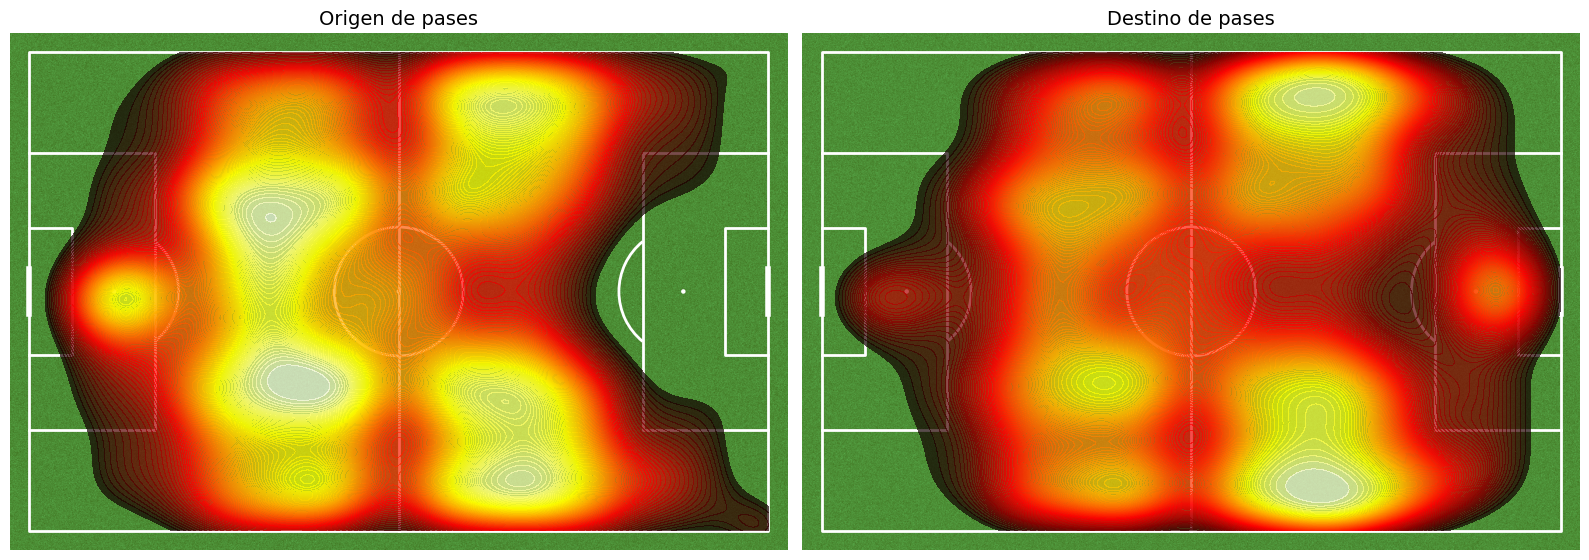

In [71]:
# heatmap ejemplo con 18k de pases (5% tarda 1 minuto)
heatmap_pases(Pases_PL_23_24[0:18000])

      x      y  count
0  60.8  100.0     20
1  40.5  100.0     20
2  32.8    0.0     19
3  55.8    0.0     18
4  29.8  100.0     18
5  85.0    0.0     18


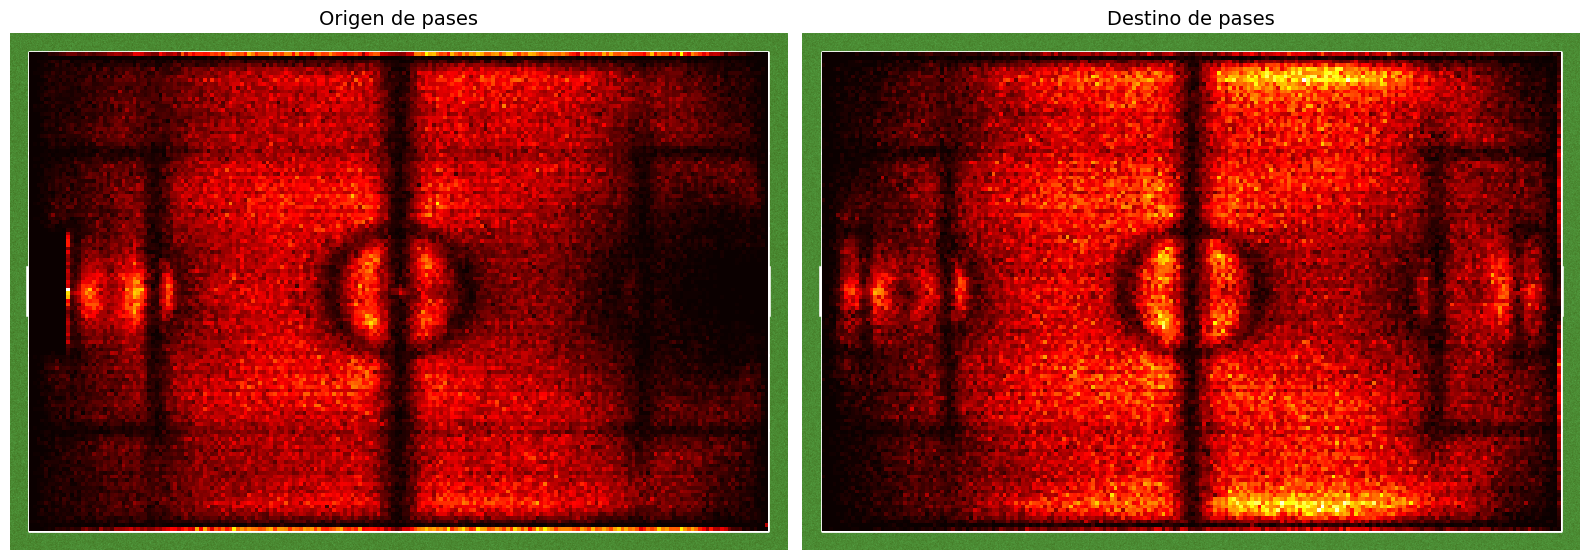

In [76]:
heatmap_pases(Pases_PL_23_24, True, bins_size=(200, 128))
# Pases_PL_23_24[0:18000][['x', 'y', 'endX', 'endY']].describe()
